# Pothole Segmentation — ResNet34‑UNet 


In [1]:
import sys, platform
print("python:", sys.version)
print("platform:", platform.platform())

import numpy as np
import torch
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


python: 3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]
platform: Linux-6.5.0-45-generic-x86_64-with-glibc2.39
numpy: 2.4.1
torch: 2.10.0+cu128
cuda: True
gpu: NVIDIA GeForce RTX 2060 SUPER


In [ ]:
import torchvision
print("torchvision:", torchvision.__version__)


torchvision: 0.25.0+cu128


In [3]:
import os, re, random, math, glob
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision.transforms.functional as TF


In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [ ]:
DATA_ROOT = Path("/workspace/dataset")  

train_img_dir = DATA_ROOT / "train" / "images"
train_msk_dir = DATA_ROOT / "train" / "mask"
test_img_dir  = DATA_ROOT / "test"  / "images"

assert train_img_dir.exists(), f"train_img_dir not found: {train_img_dir}"
assert train_msk_dir.exists(), f"train_msk_dir not found: {train_msk_dir}"
assert test_img_dir.exists(),  f"test_img_dir not found: {test_img_dir}"

print("train images:", len(list(train_img_dir.glob("*"))))
print("train masks :", len(list(train_msk_dir.glob("*"))))
print("test images :", len(list(test_img_dir.glob("*"))))


train images: 498
train masks : 498
test images : 295


In [ ]:
# ====== utils ======
def find_mask_for_image(img_path: str):
    base = os.path.splitext(os.path.basename(img_path))[0]  # train_157
    m = re.search(r"(\d+)$", base)
    if m is None:
        return None
    idx = m.group(1)
    for ext in ("png", "jpg", "jpeg"):
        c = train_msk_dir / f"mask_{idx}.{ext}"
        if c.exists():
            return str(c)
    return None

def encode_rle(mask: np.ndarray, pos_value: int = 255) -> str:
    binary = (mask == pos_value).astype(np.uint8)
    pixels = binary.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[0::2]
    return " ".join(str(x) for x in runs)

def dice_coef_np(pred_bool: np.ndarray, gt_bool: np.ndarray, eps=1e-6) -> float:
    inter = np.logical_and(pred_bool, gt_bool).sum()
    s = pred_bool.sum() + gt_bool.sum()
    if s == 0:
        return 1.0
    return float((2 * inter + eps) / (s + eps))


In [7]:
# ====== split train/val ======
VAL_RATIO = 0.2

all_imgs = sorted([p.as_posix() for p in train_img_dir.glob("*")])
assert len(all_imgs) > 0, "No training images found."

random.Random(SEED).shuffle(all_imgs)
n_val = int(len(all_imgs) * VAL_RATIO)
val_imgs = all_imgs[:n_val]
trn_imgs = all_imgs[n_val:]

print("train:", len(trn_imgs), "val:", len(val_imgs))


train: 399 val: 99


## Dataset & Transforms (tanpa Albumentations)



In [ ]:
import numpy as np
import cv2
import torch

# ImageNet normalize constants
IMNET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMNET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

@torch.no_grad()
def predict_prob(model, img_bgr, img_size=640, device=None):
    """
    Input: img_bgr (H,W,3) uint8 BGR (from cv2)
    Output: prob map (img_size, img_size) float32 0..1
    """
    if device is None:
        device = next(model.parameters()).device

    # BGR -> RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # resize to square model input
    img_rs = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0

    # normalize
    img_rs = (img_rs - IMNET_MEAN) / IMNET_STD

    # HWC -> CHW, add batch
    x = torch.from_numpy(img_rs.transpose(2,0,1)).unsqueeze(0).to(device, non_blocking=True).float()

    # forward -> sigmoid
    logits = model(x)               # (1,1,S,S)
    prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy().astype(np.float32)  # (S,S)

    return prob

@torch.no_grad()
def predict_prob_original(model, img_bgr, img_size=640, device=None):
    """
    Predict prob in model size (S,S) then upscale to original (H0,W0).
    """
    H0, W0 = img_bgr.shape[:2]
    prob_s = predict_prob(model, img_bgr, img_size=img_size, device=device)  # (S,S)
    prob_up = cv2.resize(prob_s, (W0, H0), interpolation=cv2.INTER_LINEAR)
    return prob_up  # (H0,W0)

@torch.no_grad()
def predict_prob_original_hflip(model, img_bgr, img_size=640, device=None):
    img_flip = cv2.flip(img_bgr, 1)
    prob_flip = predict_prob_original(model, img_flip, img_size=img_size, device=device)
    prob_unflip = cv2.flip(prob_flip, 1)
    return prob_unflip

@torch.no_grad()
def predict_prob_mean_multiscale_tta(model, img_bgr, sizes=(640,768), use_hflip=True, device=None):
    probs = []
    for s in sizes:
        probs.append(predict_prob_original(model, img_bgr, img_size=s, device=device))
        if use_hflip:
            probs.append(predict_prob_original_hflip(model, img_bgr, img_size=s, device=device))
    prob_mean = np.mean(np.stack(probs, axis=0), axis=0)  # (H0,W0)
    return prob_mean

def predict_prob_combo(model, img_bgr, sizes=(640,768), use_hflip=True, weights=None, device=None):
    """
    Combine multi-scale + optional hflip into ONE prob map (H0,W0).
    Ordering of probs:
      for each size s in sizes:
        prob(s), then (if use_hflip) prob(s,hflip)
    weights optional: list length must match K probs.
    """
    probs = []
    for s in sizes:
        probs.append(predict_prob_original(model, img_bgr, img_size=int(s), device=device))
        if use_hflip:
            probs.append(predict_prob_original_hflip(model, img_bgr, img_size=int(s), device=device))

    stack = np.stack(probs, axis=0).astype(np.float32)  # (K,H0,W0)

    if weights is None:
        return stack.mean(axis=0)

    w = np.array(weights, dtype=np.float32)
    assert len(w) == stack.shape[0], f"weights length {len(w)} != K {stack.shape[0]}"
    w = w / (w.sum() + 1e-8)
    return (stack * w[:, None, None]).sum(axis=0)

In [11]:
from tqdm import tqdm

def dice_bool(pred_bool: np.ndarray, gt_bool: np.ndarray, eps=1e-6) -> float:
    inter = np.logical_and(pred_bool, gt_bool).sum()
    s = pred_bool.sum() + gt_bool.sum()
    if s == 0:
        return 1.0
    return float((2.0 * inter + eps) / (s + eps))

@torch.no_grad()
def eval_val_dice_tta(model, val_img_paths, thr, sizes=(640,768), use_hflip=True, device=None):
    model.eval()
    dices = []
    empty = 0
    total = 0

    for img_path in tqdm(val_img_paths, desc=f"VAL TTA thr={thr:.3f}", leave=False):
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue

        # GT original
        mpath = find_mask_for_image(img_path)
        gt = cv2.imread(mpath, cv2.IMREAD_GRAYSCALE)
        if gt is None:
            continue
        gt_bool = (gt == 255)

        prob_mean = predict_prob_mean_multiscale_tta(
            model, img_bgr, sizes=sizes, use_hflip=use_hflip, device=device
        )
        pred_bool = (prob_mean >= float(thr))
        if pred_bool.sum() == 0:
            empty += 1

        dices.append(dice_bool(pred_bool, gt_bool))
        total += 1

    mean_dice = float(np.mean(dices)) if dices else 0.0
    empty_rate = float(empty / max(1, total))
    return mean_dice, empty_rate



In [12]:
IMG_SIZE = 640

IMNET_MEAN = (0.485, 0.456, 0.406)
IMNET_STD  = (0.229, 0.224, 0.225)

@dataclass
class AugConfig:
    hflip_p: float = 0.5
    vflip_p: float = 0.15
    rot_deg: float = 10.0
    translate: float = 0.03  # fraction
    scale_min: float = 0.95
    scale_max: float = 1.05
    brightness: float = 0.15
    contrast: float = 0.15
    saturation: float = 0.05
    hue: float = 0.02

AUG = AugConfig()

def pil_to_tensor_imnet(img_pil: Image.Image) -> torch.Tensor:
    x = TF.to_tensor(img_pil)  # [0,1] float32 CHW
    x = TF.normalize(x, IMNET_MEAN, IMNET_STD)
    return x

def mask_pil_to_tensor(mask_pil: Image.Image) -> torch.Tensor:
    m = np.array(mask_pil, dtype=np.uint8)
    m = (m == 255).astype(np.float32)  # 0/1
    return torch.from_numpy(m).unsqueeze(0)  # (1,H,W)

def apply_train_aug(img: Image.Image, mask: Image.Image, cfg: AugConfig):
    # resize first
    img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    mask = mask.resize((IMG_SIZE, IMG_SIZE), resample=Image.NEAREST)

    # flips
    if random.random() < cfg.hflip_p:
        img = TF.hflip(img); mask = TF.hflip(mask)
    if random.random() < cfg.vflip_p:
        img = TF.vflip(img); mask = TF.vflip(mask)

    # affine (mask-safe)
    angle = random.uniform(-cfg.rot_deg, cfg.rot_deg)
    max_tx = int(cfg.translate * IMG_SIZE)
    max_ty = int(cfg.translate * IMG_SIZE)
    trans = (random.randint(-max_tx, max_tx), random.randint(-max_ty, max_ty))
    scale = random.uniform(cfg.scale_min, cfg.scale_max)
    shear = 0.0

    img = TF.affine(img, angle=angle, translate=trans, scale=scale, shear=shear,
                    interpolation=TF.InterpolationMode.BILINEAR)
    mask = TF.affine(mask, angle=angle, translate=trans, scale=scale, shear=shear,
                     interpolation=TF.InterpolationMode.NEAREST)

    # color jitter (image only)
    img = TF.adjust_brightness(img, 1.0 + random.uniform(-cfg.brightness, cfg.brightness))
    img = TF.adjust_contrast(img,   1.0 + random.uniform(-cfg.contrast, cfg.contrast))
    if cfg.saturation > 0:
        img = TF.adjust_saturation(img, 1.0 + random.uniform(-cfg.saturation, cfg.saturation))
    if cfg.hue > 0:
        img = TF.adjust_hue(img, random.uniform(-cfg.hue, cfg.hue))

    return img, mask

def apply_val_tf(img: Image.Image, mask: Image.Image):
    img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    mask = mask.resize((IMG_SIZE, IMG_SIZE), resample=Image.NEAREST)
    return img, mask


In [13]:
class PotholeDataset(Dataset):
    def __init__(self, img_paths, is_train: bool):
        self.img_paths = img_paths
        self.is_train = is_train

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = find_mask_for_image(img_path)
        if mask_path is None:
            raise FileNotFoundError(f"Mask not found for {img_path}")

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.is_train:
            img, mask = apply_train_aug(img, mask, AUG)
        else:
            img, mask = apply_val_tf(img, mask)

        x = pil_to_tensor_imnet(img)
        y = mask_pil_to_tensor(mask)
        return x, y, img_path

BATCH = 8
NUM_WORKERS = 4

trn_ds = PotholeDataset(trn_imgs, is_train=True)
val_ds = PotholeDataset(val_imgs, is_train=False)

trn_loader = DataLoader(trn_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                        pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS,
                        pin_memory=True)

print("train batches:", len(trn_loader), "val batches:", len(val_loader))


train batches: 49 val batches: 13


## Model: ResNet34‑UNet (pretrained)


In [14]:
from torchvision.models import resnet34, ResNet34_Weights

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv1 = ConvBNReLU(in_ch + skip_ch, out_ch)
        self.conv2 = ConvBNReLU(out_ch, out_ch)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x

class ResNet34_UNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        m = resnet34(weights=weights)

        self.inp = nn.Sequential(m.conv1, m.bn1, m.relu)  # 64, H/2
        self.pool = m.maxpool                              # H/4

        self.enc1 = m.layer1  # 64
        self.enc2 = m.layer2  # 128
        self.enc3 = m.layer3  # 256
        self.enc4 = m.layer4  # 512

        self.center = ConvBNReLU(512, 512)
        self.up4 = UpBlock(512, 256, 256)
        self.up3 = UpBlock(256, 128, 128)
        self.up2 = UpBlock(128,  64,  64)
        self.up1 = UpBlock( 64,  64,  32)

        self.head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.inp(x)     # 64, H/2
        x = self.pool(s1)    # H/4
        s2 = self.enc1(x)    # 64, H/4
        s3 = self.enc2(s2)   # 128, H/8
        s4 = self.enc3(s3)   # 256, H/16
        s5 = self.enc4(s4)   # 512, H/32

        c  = self.center(s5)
        d4 = self.up4(c,  s4)
        d3 = self.up3(d4, s3)
        d2 = self.up2(d3, s2)
        d1 = self.up1(d2, s1)

        logits = self.head(d1)
        logits = F.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        return logits

model = ResNet34_UNet(pretrained=True).to(DEVICE)
print("model ready")


model ready


In [15]:
# ====== loss + eval ======
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(logits.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inter = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2*inter + self.eps) / (union + self.eps)
        return 1 - dice.mean()

bce = nn.BCEWithLogitsLoss()

dice_loss = DiceLoss()
def mixed_loss(logits, targets, bce_w=0.5, dice_w=0.5):
    return bce_w * bce(logits, targets) + dice_w * dice_loss(logits, targets)


@torch.no_grad()
def eval_val_dice_multi(model, loader, thrs=(0.60, 0.65, 0.70)):
    model.eval()
    dices = {float(t): [] for t in thrs}
    empties = {float(t): 0 for t in thrs}
    total = 0

    for x, y, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        prob = torch.sigmoid(model(x)).detach().cpu().numpy()
        gt   = y.detach().cpu().numpy()

        B = prob.shape[0]
        total += B
        for i in range(B):
            p = prob[i,0]
            g = (gt[i,0] >= 0.5)
            for t in thrs:
                pred = (p >= float(t))
                if pred.sum() == 0:
                    empties[float(t)] += 1
                dices[float(t)].append(dice_coef_np(pred, g))

    mean_dice = {t: float(np.mean(dices[t])) for t in dices}
    empty_rate = {t: float(empties[t] / max(1, total)) for t in empties}
    return mean_dice, empty_rate


## Training (freeze→unfreeze, 2 LR groups, cosine, early stopping)


In [17]:
import numpy as np
import torch

# ---------- helper: freeze/unfreeze encoder ----------
def set_encoder_trainable(model, trainable: bool):
    for p in model.inp.parameters():  p.requires_grad = trainable
    for p in model.enc1.parameters(): p.requires_grad = trainable
    for p in model.enc2.parameters(): p.requires_grad = trainable
    for p in model.enc3.parameters(): p.requires_grad = trainable
    for p in model.enc4.parameters(): p.requires_grad = trainable

# ---------- hyperparams ----------
EPOCHS = 50
PATIENCE = 12
LR_DEC = 1e-3
LR_ENC = 1e-4
WARMUP_EPOCHS = 3
THRS_MON = (0.60, 0.65, 0.70)

# ---------- freeze encoder first (warmup) ----------
set_encoder_trainable(model, False)

# ---------- split params (encoder vs decoder) ----------
enc_params = (
    list(model.inp.parameters()) +
    list(model.enc1.parameters()) +
    list(model.enc2.parameters()) +
    list(model.enc3.parameters()) +
    list(model.enc4.parameters())
)

enc_param_ids = set(map(id, enc_params))
dec_params = [p for p in model.parameters() if id(p) not in enc_param_ids]

print("enc params:", sum(p.numel() for p in enc_params))
print("dec params:", sum(p.numel() for p in dec_params))
assert len(enc_params) > 0 and len(dec_params) > 0
assert enc_param_ids.isdisjoint(set(map(id, dec_params)))

# ---------- optimizer & scheduler ----------
opt = torch.optim.AdamW(
    [
        {"params": enc_params, "lr": LR_ENC},
        {"params": dec_params, "lr": LR_DEC},
    ],
    weight_decay=1e-4
)

sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

# ---------- training loop ----------
best_path = "./resunet_best.pt"
best_val = -1.0
no_improve = 0

print("Start training...")
for epoch in range(1, EPOCHS + 1):
    model.train()

    # unfreeze encoder after warmup
    if epoch == WARMUP_EPOCHS + 1:
        set_encoder_trainable(model, True)
        print("Unfreeze encoder (encoder LR tetap kecil via 2LR groups).")

    losses = []
    for x, y, _ in trn_loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        logits = model(x)
        loss = mixed_loss(logits, y, bce_w=0.5, dice_w=0.5)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        losses.append(float(loss.item()))

    sched.step()
    tr_loss = float(np.mean(losses)) if losses else 0.0

    mean_dice, empty_rate = eval_val_dice_multi(model, val_loader, thrs=THRS_MON)
    val_score = mean_dice[0.65]

    lr_enc = opt.param_groups[0]["lr"]
    lr_dec = opt.param_groups[1]["lr"]

    print(
        f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | "
        f"val@0.60={mean_dice[0.60]:.4f} (empty {empty_rate[0.60]*100:.1f}%) | "
        f"val@0.65={mean_dice[0.65]:.4f} (empty {empty_rate[0.65]*100:.1f}%) | "
        f"val@0.70={mean_dice[0.70]:.4f} (empty {empty_rate[0.70]*100:.1f}%) | "
        f"lr_enc={lr_enc:.2e} lr_dec={lr_dec:.2e}"
    )

    if val_score > best_val + 1e-4:
        best_val = val_score
        torch.save(model.state_dict(), best_path)
        no_improve = 0
        print("  ✓ saved best:", best_path, "| best_val@0.65:", best_val)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

print("Done. Best val@0.65:", best_val)


enc params: 21284672
dec params: 5504929
Start training...
Epoch 001 | train_loss=0.5981 | val@0.60=0.5401 (empty 6.1%) | val@0.65=0.5354 (empty 6.1%) | val@0.70=0.5266 (empty 6.1%) | lr_enc=9.99e-05 lr_dec=9.99e-04
  ✓ saved best: ./resunet_best.pt | best_val@0.65: 0.5353917912180439
Epoch 002 | train_loss=0.4911 | val@0.60=0.5141 (empty 8.1%) | val@0.65=0.4932 (empty 8.1%) | val@0.70=0.4675 (empty 9.1%) | lr_enc=9.96e-05 lr_dec=9.96e-04
Epoch 003 | train_loss=0.4365 | val@0.60=0.2385 (empty 17.2%) | val@0.65=0.1981 (empty 23.2%) | val@0.70=0.1568 (empty 26.3%) | lr_enc=9.91e-05 lr_dec=9.91e-04
Unfreeze encoder (encoder LR tetap kecil via 2LR groups).
Epoch 004 | train_loss=0.3880 | val@0.60=0.6075 (empty 6.1%) | val@0.65=0.5993 (empty 6.1%) | val@0.70=0.5875 (empty 6.1%) | lr_enc=9.84e-05 lr_dec=9.84e-04
  ✓ saved best: ./resunet_best.pt | best_val@0.65: 0.5992715338065857
Epoch 005 | train_loss=0.3376 | val@0.60=0.6534 (empty 3.0%) | val@0.65=0.6556 (empty 3.0%) | val@0.70=0.6557 (e

## Threshold Sweep (Multi-scale)

cache[w(0.7@640)+flip]: 100%|██████████| 99/99 [00:31<00:00,  3.13it/s]


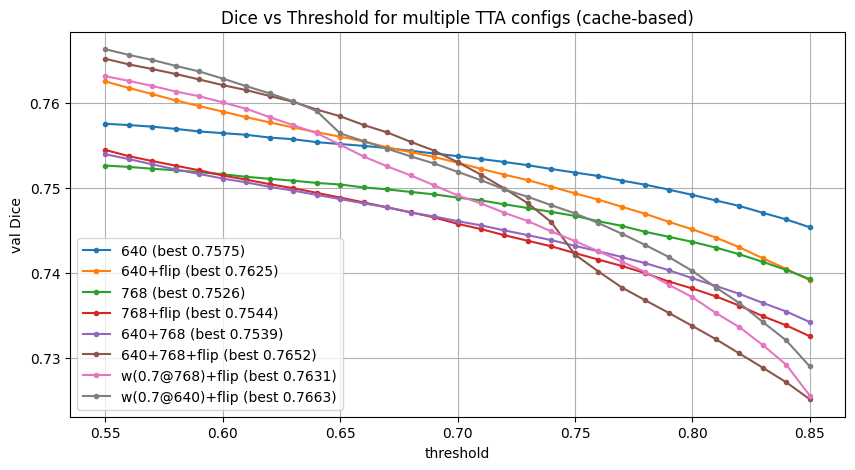

Top configs (name, best_thr, best_dice, empty):
('w(0.7@640)+flip', 0.55, 0.7662715315818787, 0.0)
('640+768+flip', 0.55, 0.7651513814926147, 0.0)
('w(0.7@768)+flip', 0.55, 0.7630981802940369, 0.0)
('640+flip', 0.55, 0.7624830007553101, 0.0)
('640', 0.55, 0.7575052380561829, 0.0)
('768+flip', 0.55, 0.754429280757904, 0.0)
('640+768', 0.55, 0.7539171576499939, 0.0)
('768', 0.55, 0.7525886297225952, 0.0)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

# ===== configs (WAJIB ADA) =====
configs = [
    {"name":"640",         "sizes":(640,),      "use_hflip":False},
    {"name":"640+flip",    "sizes":(640,),      "use_hflip":True},
    {"name":"768",         "sizes":(768,),      "use_hflip":False},
    {"name":"768+flip",    "sizes":(768,),      "use_hflip":True},
    {"name":"640+768",     "sizes":(640,768),   "use_hflip":False},
    {"name":"640+768+flip","sizes":(640,768),   "use_hflip":True},
    # weighted: K probs = 2 sizes * (flip?2:1) => 4 maps
    {"name":"w(0.7@768)+flip", "sizes":(640,768), "use_hflip":True, "weights":[0.15,0.15,0.35,0.35]},  # 640,640flip,768,768flip
    {"name":"w(0.7@640)+flip", "sizes":(640,768), "use_hflip":True, "weights":[0.35,0.35,0.15,0.15]},
]

# ===== cache builder =====
def build_cache_for_config(model, val_imgs, cfg):
    cache = []
    for img_path in tqdm(val_imgs, desc=f"cache[{cfg['name']}]"):
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        mpath = find_mask_for_image(img_path)
        gt = cv2.imread(mpath, cv2.IMREAD_GRAYSCALE)
        if gt is None:
            continue
        g = (gt == 255)

        prob = predict_prob_combo(
            model, img_bgr,
            sizes=cfg["sizes"],
            use_hflip=cfg["use_hflip"],
            weights=cfg.get("weights", None),
        )

        cache.append({"prob": prob.astype(np.float16), "gt": g})
    return cache

# ===== fast sweep from cache =====
def sweep_from_cache(cache, thr_list):
    dices_curve = []
    empties_curve = []
    for thr in thr_list:
        dices = []
        empty = 0
        for item in cache:
            prob = item["prob"]
            gt = item["gt"]
            pred = (prob >= float(thr))
            if pred.sum() == 0:
                empty += 1
            dices.append(dice_coef_np(pred, gt))
        dices_curve.append(float(np.mean(dices)) if dices else 0.0)
        empties_curve.append(float(empty / max(1, len(cache))))
    return np.array(dices_curve, np.float32), np.array(empties_curve, np.float32)

# ===== run comparison =====
thr_list = np.linspace(0.55, 0.85, 31)

plt.figure(figsize=(10,5))
best_summary = []

for cfg in configs:
    cache = build_cache_for_config(model, val_imgs, cfg)   # inference sekali per image
    dice_curve, empty_curve = sweep_from_cache(cache, thr_list)

    best_i = int(np.argmax(dice_curve))
    best_summary.append((cfg["name"], float(thr_list[best_i]), float(dice_curve[best_i]), float(empty_curve[best_i])))
    plt.plot(thr_list, dice_curve, marker=".", label=f'{cfg["name"]} (best {dice_curve[best_i]:.4f})')

plt.xlabel("threshold")
plt.ylabel("val Dice")
plt.title("Dice vs Threshold for multiple TTA configs (cache-based)")
plt.grid(True)
plt.legend()
plt.show()

print("Top configs (name, best_thr, best_dice, empty):")
best_summary = sorted(best_summary, key=lambda x: x[2], reverse=True)
for row in best_summary[:8]:
    print(row)


cache[640+768+flip]: 100%|██████████| 99/99 [00:31<00:00,  3.18it/s]


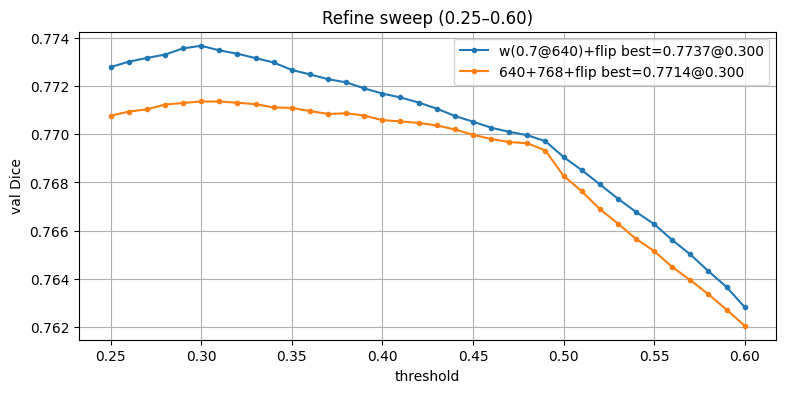

BEST A: {'name': 'w(0.7@640)+flip', 'thr': 0.3, 'dice': 0.7736755609512329, 'empty': 0.0}
BEST B: {'name': '640+768+flip', 'thr': 0.3, 'dice': 0.7713629007339478, 'empty': 0.0}


In [20]:
import numpy as np
import matplotlib.pyplot as plt

CFG_A = {"name":"w(0.7@640)+flip", "sizes":(640,768), "use_hflip":True, "weights":[0.35,0.35,0.15,0.15]}
CFG_B = {"name":"640+768+flip",    "sizes":(640,768), "use_hflip":True}

def run_refine_for_cfg(model, val_imgs, cfg, lo=0.25, hi=0.60, n=36):
    thr_list = np.linspace(lo, hi, n)
    cache = build_cache_for_config(model, val_imgs, cfg)
    dice_curve, empty_curve = sweep_from_cache(cache, thr_list)
    best_i = int(np.argmax(dice_curve))
    best = {
        "name": cfg["name"],
        "thr": float(thr_list[best_i]),
        "dice": float(dice_curve[best_i]),
        "empty": float(empty_curve[best_i]),
        "thr_list": thr_list,
        "dice_curve": dice_curve,
        "empty_curve": empty_curve,
    }
    return best
    
bestA = run_refine_for_cfg(model, val_imgs, CFG_A, lo=0.25, hi=0.60, n=36)
bestB = run_refine_for_cfg(model, val_imgs, CFG_B, lo=0.25, hi=0.60, n=36)

plt.figure(figsize=(9,4))
plt.plot(bestA["thr_list"], bestA["dice_curve"], marker=".", label=f'{bestA["name"]} best={bestA["dice"]:.4f}@{bestA["thr"]:.3f}')
plt.plot(bestB["thr_list"], bestB["dice_curve"], marker=".", label=f'{bestB["name"]} best={bestB["dice"]:.4f}@{bestB["thr"]:.3f}')
plt.grid(True); plt.xlabel("threshold"); plt.ylabel("val Dice"); plt.legend(); plt.title("Refine sweep (0.25–0.60)")
plt.show()

print("BEST A:", {k:bestA[k] for k in ["name","thr","dice","empty"]})
print("BEST B:", {k:bestB[k] for k in ["name","thr","dice","empty"]})


In [ ]:
import os, glob, random
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

CFG_FINAL = {
    "name": "w(0.7@640)+flip",
    "sizes": (640, 768),
    "use_hflip": True,
    "weights": [0.35, 0.35, 0.15, 0.15],
}
FINAL_THR = 0.30

IMNET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMNET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_bgr_to_tensor(img_bgr: np.ndarray, device: str):
    """
    img_bgr: uint8 HxWx3
    return: torch float32 1x3xHxW normalized
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_rgb = (img_rgb - IMNET_MEAN) / IMNET_STD
    x = torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0)  # 1x3xHxW
    return x.to(device)

@torch.no_grad()
def predict_prob_at_size(model, img_bgr, img_size: int, device: str, use_amp: bool = True):
    """
    Predict prob map at square img_size, then return prob in that square size.
    """
    # resize to square
    img_rs = cv2.resize(img_bgr, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    x = preprocess_bgr_to_tensor(img_rs, device)

    model.eval()
    if use_amp and (device.startswith("cuda")):
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(x)
    else:
        logits = model(x)

    prob = torch.sigmoid(logits)[0,0].detach().float().cpu().numpy()  # (S,S)
    return prob

@torch.no_grad()
def predict_prob_at_size_hflip(model, img_bgr, img_size: int, device: str, use_amp: bool = True):
    """
    Hflip TTA: flip input, predict, flip prob back
    """
    img_flip = cv2.flip(img_bgr, 1)  # horizontal flip
    p = predict_prob_at_size(model, img_flip, img_size, device, use_amp=use_amp)
    p = np.fliplr(p)  # flip back
    return p

def resize_prob_to_original(prob_square: np.ndarray, orig_hw):
    """
    prob_square: (S,S)
    orig_hw: (H,W)
    return: (H,W)
    """
    H, W = orig_hw
    return cv2.resize(prob_square, (W, H), interpolation=cv2.INTER_LINEAR)

def predict_prob_combo_original(model, img_bgr, cfg, device: str, use_amp: bool = True):
    """
    Multi-scale (+ optional hflip) dan output prob dikembalikan ke ukuran asli image (H,W).
    cfg: {"sizes":(640,768), "use_hflip":True/False, "weights":[...]} optional
    return: prob_mean (H,W) float32
    """
    H, W = img_bgr.shape[:2]
    probs = []

    for s in cfg["sizes"]:
        p = predict_prob_at_size(model, img_bgr, int(s), device, use_amp=use_amp)
        p = resize_prob_to_original(p, (H,W))
        probs.append(p)

        if cfg.get("use_hflip", False):
            pf = predict_prob_at_size_hflip(model, img_bgr, int(s), device, use_amp=use_amp)
            pf = resize_prob_to_original(pf, (H,W))
            probs.append(pf)

    stack = np.stack(probs, axis=0).astype(np.float32)  # (K,H,W)

    weights = cfg.get("weights", None)
    if weights is None:
        return stack.mean(axis=0)

    w = np.array(weights, dtype=np.float32)
    if len(w) != stack.shape[0]:
        raise ValueError(f"weights length {len(w)} != num preds {stack.shape[0]}. "
                         f"Expected K = sizes*(1 or 2 if hflip).")
    w = w / (w.sum() + 1e-8)
    return (stack * w[:, None, None]).sum(axis=0)

def binarize(prob, thr: float):
    return (prob >= float(thr)).astype(np.uint8)


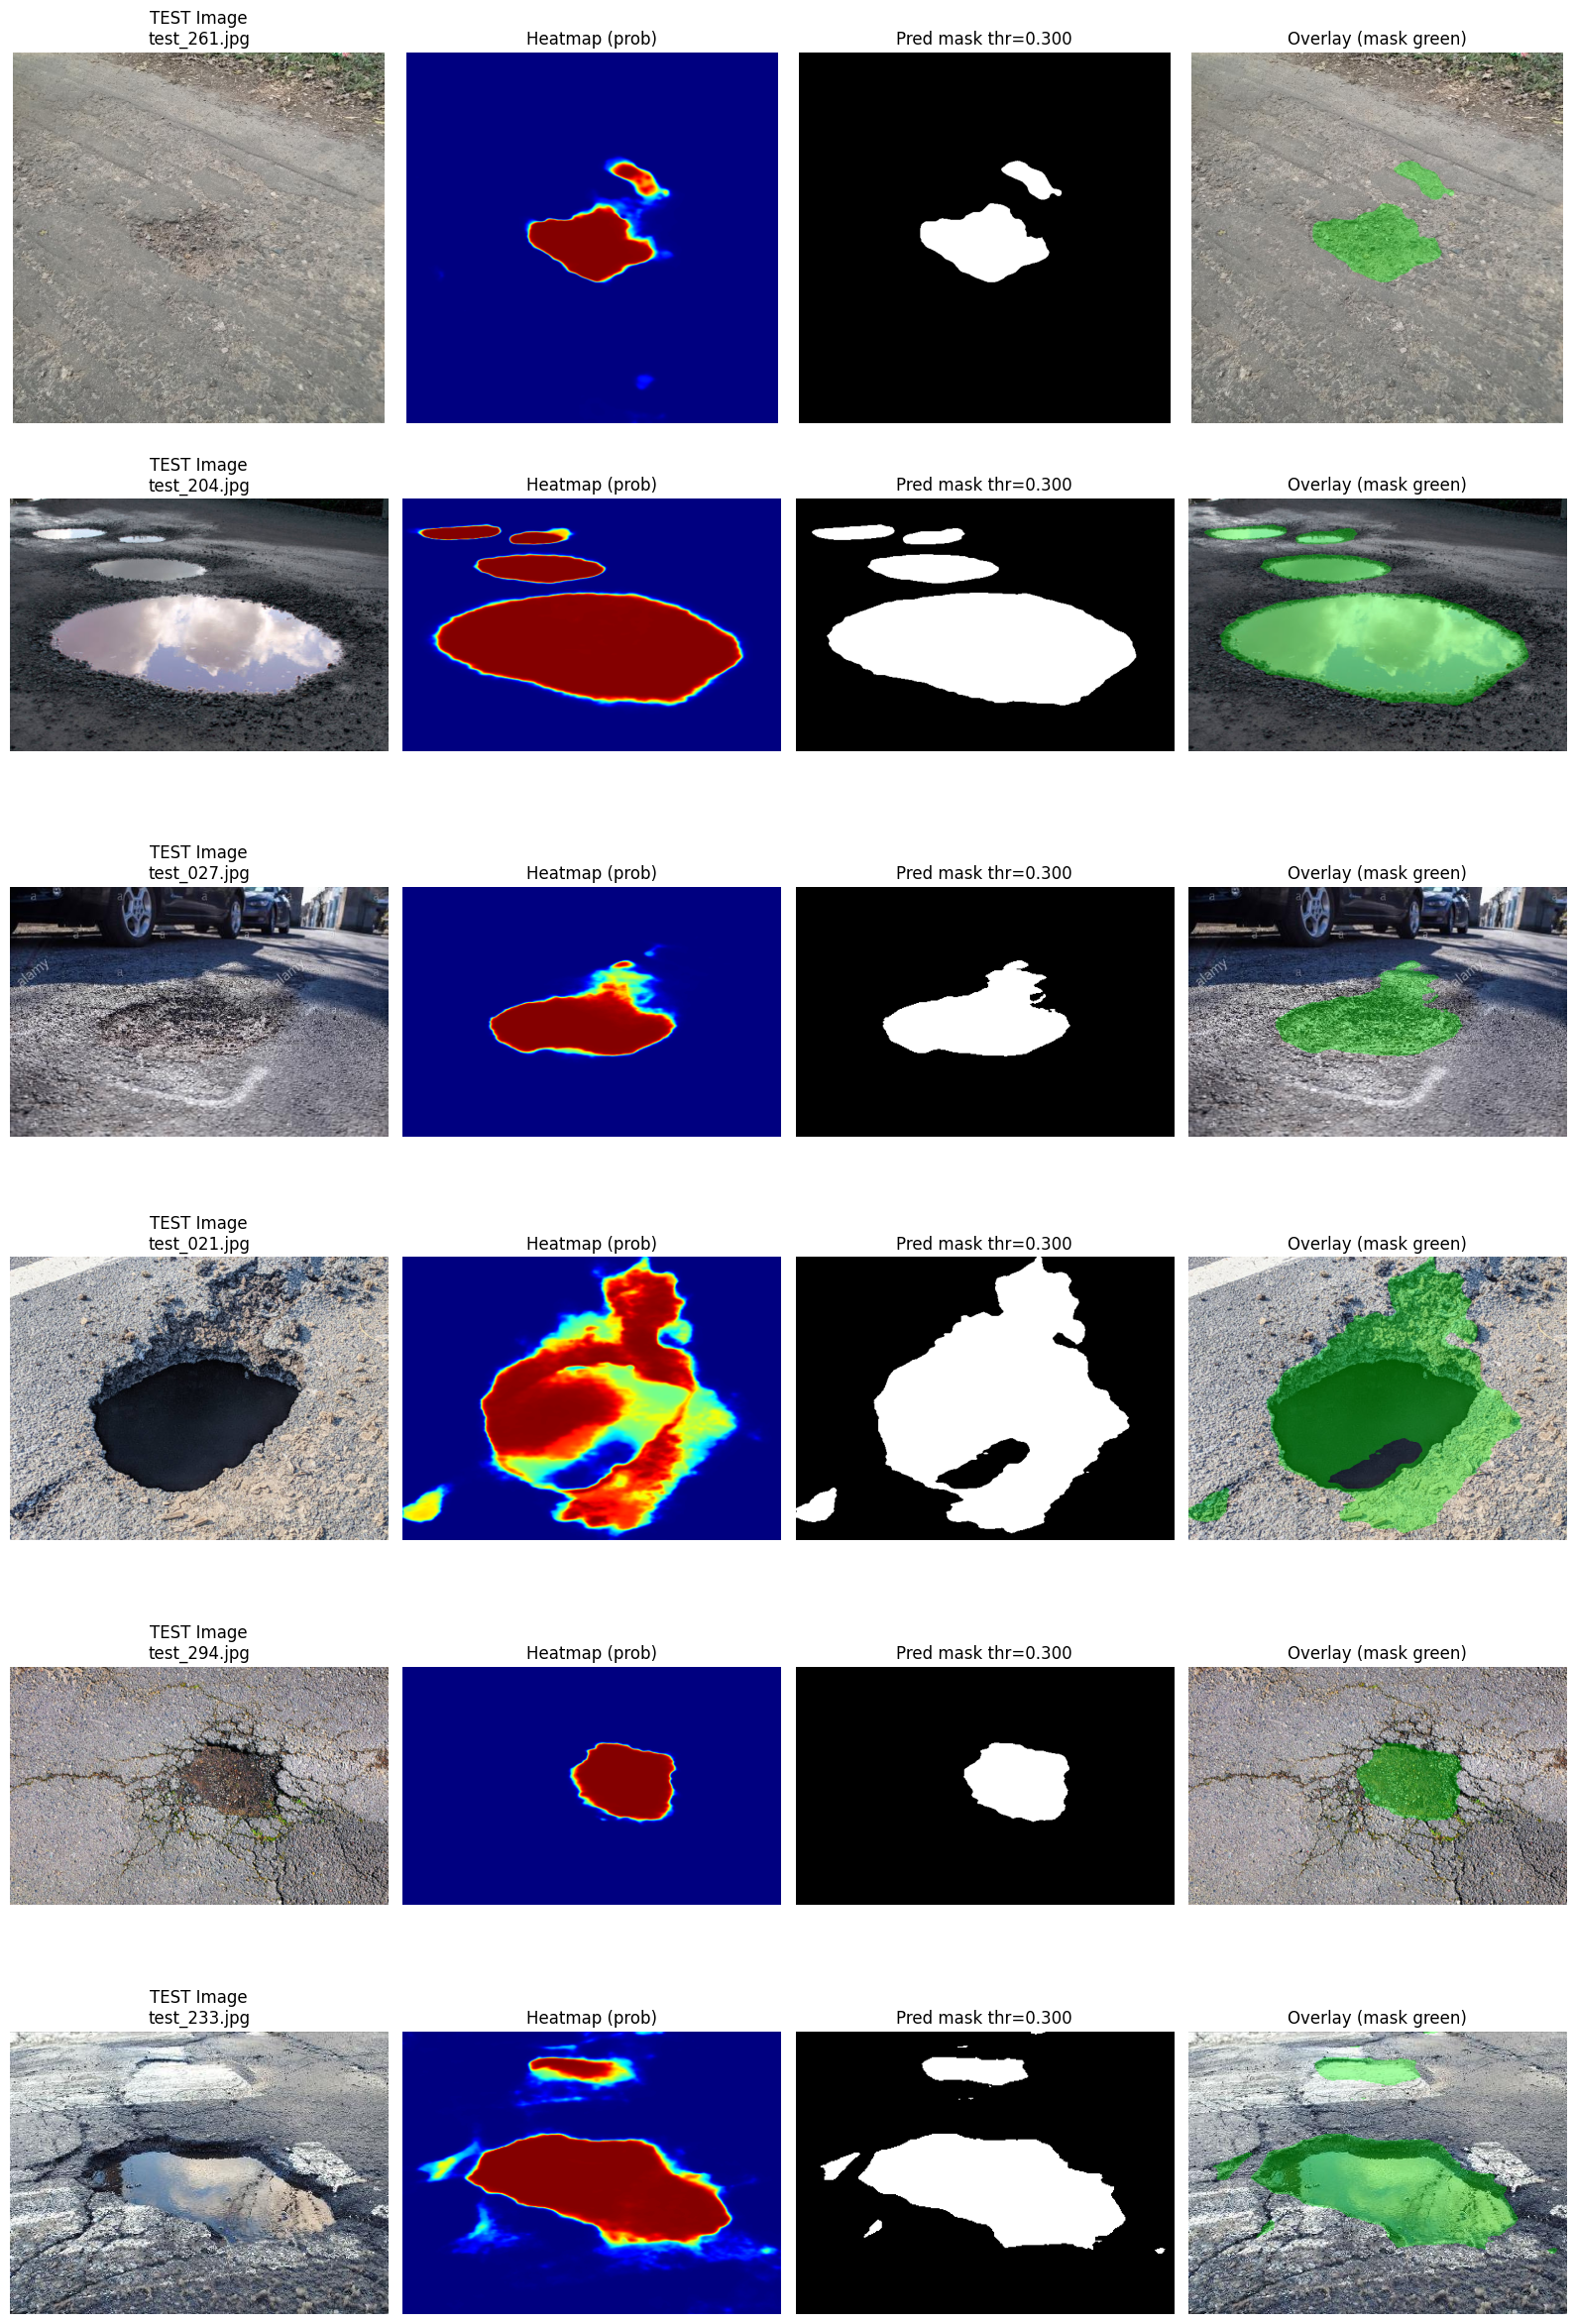

In [24]:
def overlay_mask_on_image(img_bgr, mask01, color=(0,255,0), alpha=0.35):
    """
    overlay mask (green default) on bgr image
    """
    out = img_bgr.copy()
    m = mask01.astype(bool)
    overlay = out.copy()
    overlay[m] = color
    out = cv2.addWeighted(overlay, alpha, out, 1-alpha, 0)
    return out

def show_preview_images(model, img_paths, cfg, thr, n=6, seed=42, title_prefix=""):
    random.seed(seed)
    paths = img_paths[:]
    random.shuffle(paths)
    paths = paths[:n]

    rows = len(paths)
    plt.figure(figsize=(16, 4*rows))

    for i, p in enumerate(paths, 1):
        img_bgr = cv2.imread(p)
        if img_bgr is None:
            print("skip unreadable:", p)
            continue

        prob = predict_prob_combo_original(model, img_bgr, cfg, device=DEVICE, use_amp=True)
        pred01 = binarize(prob, thr)

        heat = (prob * 255).clip(0,255).astype(np.uint8)
        heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
        heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)

        overlay = overlay_mask_on_image(img_bgr, pred01, color=(0,255,0), alpha=0.35)
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # plotting: Image | Heatmap | Pred mask | Overlay
        plt.subplot(rows, 4, (i-1)*4 + 1); plt.imshow(img_rgb); plt.axis("off"); plt.title(f"{title_prefix}Image\n{os.path.basename(p)}")
        plt.subplot(rows, 4, (i-1)*4 + 2); plt.imshow(heat); plt.axis("off"); plt.title("Heatmap (prob)")
        plt.subplot(rows, 4, (i-1)*4 + 3); plt.imshow(pred01, cmap="gray"); plt.axis("off"); plt.title(f"Pred mask thr={thr:.3f}")
        plt.subplot(rows, 4, (i-1)*4 + 4); plt.imshow(overlay_rgb); plt.axis("off"); plt.title("Overlay (mask green)")

    plt.tight_layout()
    plt.show()

test_img_dir = "/workspace/dataset/test/images"
test_paths = sorted(glob.glob(os.path.join(test_img_dir, "*.jpg")))
show_preview_images(model, test_paths, CFG_FINAL, FINAL_THR, n=6, seed=42, title_prefix="TEST ")

## Inference + Submission (OpenCV)


In [ ]:
import os, glob
import pandas as pd
from tqdm import tqdm
import cv2
import numpy as np
import torch

def make_submission_kaggle_ImageId_rle(
    model,
    test_img_dir,
    cfg,
    thr: float,
    out_csv="submission.csv",
    exts=("jpg","png","jpeg"),
):
    # collect test images
    test_paths = []
    for e in exts:
        test_paths += glob.glob(os.path.join(test_img_dir, f"*.{e}"))
    test_paths = sorted(test_paths)
    assert len(test_paths) > 0, f"No images found in {test_img_dir}"

    rows = []
    model.eval()

    for p in tqdm(test_paths, desc="Infer test -> RLE"):
        img_bgr = cv2.imread(p)
        if img_bgr is None:
            print("skip unreadable:", p)
            continue

        # prob in ORIGINAL size (H,W)
        prob = predict_prob_combo_original(model, img_bgr, cfg, device=DEVICE, use_amp=True)

        # binarize
        pred01 = (prob >= float(thr)).astype(np.uint8)

        # rle (empty string if empty mask)
        rle = encode_rle(pred01) if pred01.sum() > 0 else ""

        rows.append({
            "ImageId": os.path.basename(p),
            "rle": rle
        })

    sub = pd.DataFrame(rows, columns=["ImageId", "rle"])
    sub.to_csv(out_csv, index=False)
    print("Saved:", out_csv, "| rows:", len(sub))
    return sub

# ==== RUN ====
sub = make_submission_kaggle_ImageId_rle(model, test_img_dir, CFG_FINAL, FINAL_THR, out_csv="submission.csv")
sub.head()



Infer test -> RLE: 100%|██████████| 295/295 [00:38<00:00,  7.75it/s]

Saved: submission.csv | rows: 295


,ImageId,rle
0,test_001.jpg,4941 3 5239 6 5539 7 5838 8 6137 9 6436 11 673...
1,test_002.jpg,65721 5 66439 8 67158 9 67877 11 68596 12 6931...
2,test_003.jpg,1620844 3 1623138 5 1625433 7 1627729 8 163002...
3,test_004.jpg,1002 1 1301 2 1601 2 1901 3 2201 3 2501 2 2801...
4,test_005.jpg,50528 5 50824 11 51123 13 51423 15 51723 17 52...
